# 05 — Decision Threshold

Choose the approval threshold by expected cost, not by the default 0.5 classifier cutoff.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..', 'src').resolve()))

import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

from credit_risk import data, fairness, threshold

MODELS_DIR = Path('..', 'models')
FIG_DIR = Path('..', 'reports', 'figures')
TABLE_DIR = Path('..', 'reports', 'tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

raw = data.load_raw()
train_df, test_df = data.train_test_split_data(raw)
feats = data.feature_columns(raw)
X_train, y_train = train_df[feats], train_df[data.TARGET]
X_test, y_test = test_df[feats], test_df[data.TARGET]
protected_test = test_df[list(data.PROTECTED)].copy()

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(MODELS_DIR / 'xgboost_model.json')
score_xgb = xgb_model.predict_proba(X_test)[:, 1]
chosen_threshold = threshold.optimal_threshold(y_test.to_numpy(), score_xgb).best_threshold
print(f'test_rows={len(test_df):,}')
print(f'chosen_threshold={chosen_threshold:.3f}')


test_rows=7,500
chosen_threshold=0.151


In [2]:
chosen = threshold.optimal_threshold(y_test.to_numpy(), score_xgb, cost_fn=5.0, cost_fp=1.0)
threshold_comparison = pd.DataFrame(
    [
        {'policy': 'naive_0_5_cutoff', **threshold.threshold_outcomes(y_test.to_numpy(), score_xgb, 0.5, cost_fn=5.0, cost_fp=1.0)},
        {'policy': 'cost_based_threshold', **threshold.threshold_outcomes(y_test.to_numpy(), score_xgb, chosen.best_threshold, cost_fn=5.0, cost_fp=1.0)},
    ]
)
threshold_comparison.to_csv(TABLE_DIR / 'threshold_comparison.csv', index=False)
print('cost_of_default_vs_declined_good=5:1')
print(threshold_comparison.round(4).to_string(index=False))


cost_of_default_vs_declined_good=5:1
              policy  threshold  approval_rate  approved_default_rate  expected_cost  expected_profit
    naive_0_5_cutoff     0.5000         0.8749                 0.1567         0.7263           0.0525
cost_based_threshold     0.1508         0.5315                 0.0941         0.5473           0.2315


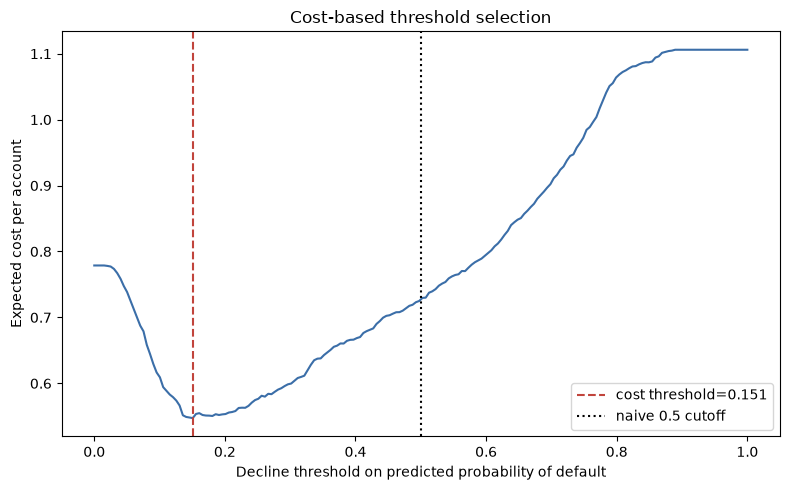

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
curve = chosen.curve.copy()
ax.plot(curve['threshold'], curve['expected_cost'], color='#3B6EA8')
ax.axvline(chosen.best_threshold, color='#C1443C', linestyle='--', label=f'cost threshold={chosen.best_threshold:.3f}')
ax.axvline(0.5, color='black', linestyle=':', label='naive 0.5 cutoff')
ax.set_xlabel('Decline threshold on predicted probability of default')
ax.set_ylabel('Expected cost per account')
ax.set_title('Cost-based threshold selection')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'cost_threshold_curve.png', dpi=160)
plt.show()


## Fairness metrics at the chosen threshold

In [4]:
def group_labels(frame):
    return {
        'SEX': frame['SEX'].map({1: 'Male', 2: 'Female'}),
        'AGE band': fairness.bucket_age(frame['AGE']).astype(str),
        'MARRIAGE': frame['MARRIAGE'].map({1: 'married', 2: 'single', 3: 'other'}).fillna('undocumented'),
    }

all_tables = []
for attribute, labels in group_labels(protected_test).items():
    table = fairness.approval_fairness_table(
        y_test.to_numpy(), score_xgb, chosen_threshold, labels
    )
    table.insert(0, 'attribute', attribute)
    table['tpr_gap_for_attribute'] = fairness.true_positive_rate_gap(table)
    all_tables.append(table)

fairness_audit = pd.concat(all_tables, ignore_index=True)
fairness_audit.to_csv(TABLE_DIR / 'fairness_at_decision_threshold.csv', index=False)
print(fairness_audit.round(4).to_string(index=False))
print('\nAny disparate-impact flags below 0.8?')
print(fairness_audit.loc[fairness_audit['di_flag_below_0_8'], ['attribute', 'group', 'disparate_impact_ratio']].round(3).to_string(index=False))


attribute        group    n  approval_rate  actual_default_rate  mean_predicted_pd  calibration_error  true_positive_rate  disparate_impact_ratio  di_flag_below_0_8  tpr_gap_for_attribute
      SEX       Female 4605         0.5496               0.2056             0.2130             0.0074              0.7730                  1.0000              False                 0.0023
      SEX         Male 2895         0.5026               0.2459             0.2366            -0.0093              0.7753                  0.9144              False                 0.0023
 AGE band        26-35 3273         0.5622               0.1937             0.2103             0.0166              0.7744                  1.0000              False                 0.1314
 AGE band        36-45 2114         0.5445               0.2332             0.2167            -0.0165              0.7525                  0.9685              False                 0.1314
 AGE band        46-55  953         0.5215               0.2